In [2]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [3]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

dog_breed_identification_path = kagglehub.competition_download('dog-breed-identification')

print('Data source import complete.')


100%|██████████| 691M/691M [00:04<00:00, 162MB/s]

Extracting files...


Data source import complete.


In [4]:
import os
import zipfile

from google.colab import files


os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
!pip install -q kaggle

!kaggle competitions download -c dog-breed-identification
with zipfile.ZipFile("dog-breed-identification.zip", 'r') as zip_ref:
    zip_ref.extractall("dog-breed-identification")



 98% 674M/691M [00:01<00:00, 273MB/s]
100% 691M/691M [00:01<00:00, 364MB/s]


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models
from tqdm import tqdm
import os
import math
import glob
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torch.utils.data import Dataset, Subset, DataLoader
import matplotlib.pyplot as plt
import pickle

In [6]:
torch.manual_seed(2022)
device = torch.device('cuda')

print(f'Current Device : {device}')

Current Device : cuda


In [7]:
img_names = glob.glob("dog-breed-identification/train/*.jpg")
print(f'Total images in Dataset : {len(img_names)}')

Total images in Dataset : 10222


In [8]:
class DogDataset(Dataset):

    def __init__(self, img_path, csv_path):
        self.csv_path = csv_path
        self.transform = None
        self.img_names = glob.glob(f"{img_path}/*.jpg")

        if csv_path:
            label_df = pd.read_csv(csv_path)
            self.label_idx2name = label_df['breed'].unique()
            self.label_name2idx = {}
            for i in range(len(self.label_idx2name)):
                self.label_name2idx[self.label_idx2name[i]] = i
            self.img2label = {}
            for _, row in label_df.iterrows():
                self.img2label[f"{img_path}/{row['id']}.jpg"] = self.label_name2idx[row['breed']]

    def __len__(self):
        return len(self.img_names)

    def __getitem__(self, index):
        img = self.img_names[index]
        if self.csv_path:
            label = self.img2label[img]
            label = torch.tensor(label)
        else:
            label = -1

        img = Image.open(img).convert("RGB")
        img = self.transform(img)
        return (img, label)

In [9]:
channel_mean = torch.Tensor([0.485, 0.456, 0.406])
channel_std = torch.Tensor([0.229, 0.224, 0.225])

vit_train_transform_fn = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(p=0.6),
    transforms.RandomRotation(degrees=(30)),
    transforms.ToTensor(),
    transforms.Normalize(mean=channel_mean, std=channel_std),
])

vit_valid_transform_fn = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=channel_mean, std=channel_std),
])

In [10]:
dataset = DogDataset(
    img_path="dog-breed-identification/train",
    csv_path="dog-breed-identification/labels.csv",
)

In [11]:
indexes = list(range(len(dataset)))
train_indexes, valid_indexes = train_test_split(indexes, test_size=0.1)
train_dataset = Subset(dataset, train_indexes)
valid_dataset = Subset(dataset, valid_indexes)

print(f"Number of samples in train_dataset: {len(train_dataset)}")
print(f"Number of samples in valid_dataset: {len(valid_dataset)}")

Number of samples in train_dataset: 9199
Number of samples in valid_dataset: 1023


In [12]:
dataset.transform = vit_train_transform_fn
train_dataset.transform = vit_train_transform_fn
valid_dataset.transform = vit_valid_transform_fn

In [13]:
train_valid_dataloader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True
)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

valid_dataloader = DataLoader(
    valid_dataset,
    batch_size=32,
    shuffle=True
)

In [14]:
def show_samples(batch_img, batch_label=None, num_samples=16):
    sample_idx = 0
    total_col = 4
    total_row = math.ceil(num_samples / 4)
    col_idx = 0
    row_idx = 0
    fig, axs = plt.subplots(total_row, total_col, figsize=(15, 15))

    while sample_idx < num_samples:
        img = batch_img[sample_idx]
        img = img.view(3, -1) * channel_std.view(3, -1) + channel_mean.view(3, -1)
        img = img.view(3, 224, 224)
        img = img.permute(1, 2, 0)
        axs[row_idx, col_idx].imshow(img)

        if batch_label != None:
            axs[row_idx, col_idx].set_title(dataset.label_idx2name[(batch_label[sample_idx])])

        sample_idx += 1
        col_idx += 1
        if col_idx == 4:
            col_idx = 0
            row_idx += 1

In [15]:
batch_img, batch_label = next(iter(train_dataloader))

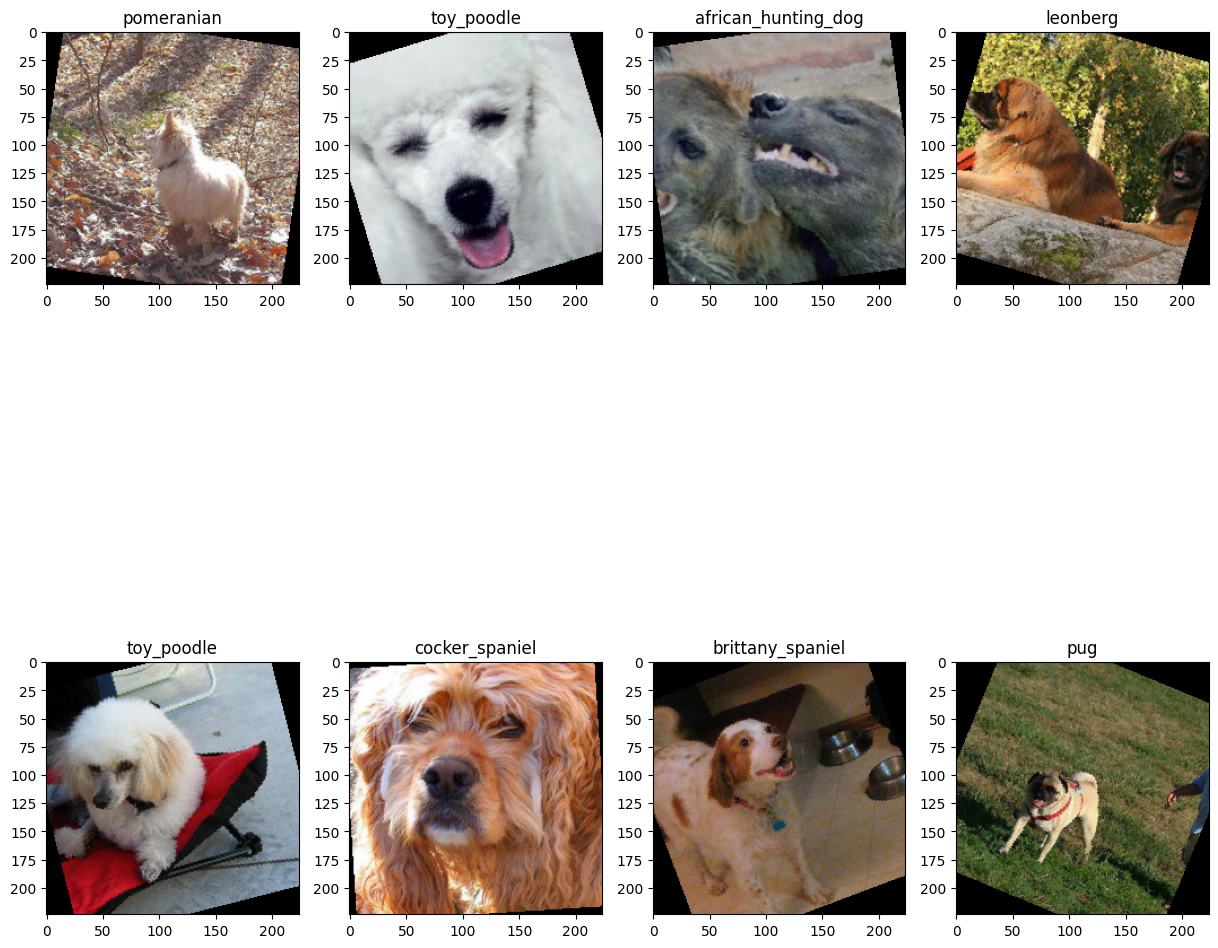

In [16]:
show_samples(batch_img, batch_label, 8)

In [17]:
class PretrainViT(nn.Module):

    def __init__(self):
        super(PretrainViT, self).__init__()
        model = models.vit_l_16(pretrained=True)
        num_classifier_feature = model.heads.head.in_features
        model.heads.head = nn.Sequential(
            nn.Linear(num_classifier_feature, 120)
        )
        self.model = model
        for param in self.model.named_parameters():
            if "heads" not in param[0]:
                param[1].requires_grad = False

    def forward(self, x):
        return self.model(x)

In [18]:
net = PretrainViT()
net.to(device)
print(f"number of paramaters: {sum([param.numel() for param in net.parameters() if param.requires_grad])}")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_L_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_L_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vit_l_16-852ce7e3.pth" to /root/.cache/torch/hub/checkpoints/vit_l_16-852ce7e3.pth
100%|██████████| 1.13G/1.13G [00:11<00:00, 106MB/s]


number of paramaters: 123000


In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.009, momentum=0.9)

In [20]:
def get_accuracy(output, label):
    output = output.to("cpu")
    label = label.to("cpu")
    sm = F.softmax(output, dim=1)
    _, index = torch.max(sm, dim=1)
    return torch.sum((label == index)) / label.size()[0]

In [21]:
def train(model, dataloader):
    model.train()
    running_loss = 0.0
    total_loss = 0.0
    running_acc = 0.0
    total_acc = 0.0

    for batch_idx, (batch_img, batch_label) in enumerate(dataloader):
        batch_img = batch_img.to(device)
        batch_label = batch_label.to(device)
        optimizer.zero_grad()
        output = net(batch_img)
        loss = criterion(output, batch_label)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        total_loss += loss.item()
        acc = get_accuracy(output, batch_label)
        running_acc += acc
        total_acc += acc
        if batch_idx % 100 == 0 and batch_idx != 0:
            print(f"[step: {batch_idx:4d}/{len(dataloader)}] loss: {running_loss / 100:.3f}")
            running_loss = 0.0
            running_acc = 0.0

    return total_loss / len(dataloader), total_acc / len(dataloader)

In [22]:
def validate(model, dataloader):
    model.eval()
    total_loss = 0.0
    total_acc = 0.0

    for batch_idx, (batch_img, batch_label) in enumerate(dataloader):
        batch_img = batch_img.to(device)
        batch_label = batch_label.to(device)
        output = net(batch_img)
        loss = criterion(output, batch_label)
        total_loss += loss.item()
        acc = get_accuracy(output, batch_label)
        total_acc += acc

    return total_loss / len(dataloader), total_acc / len(dataloader)

In [23]:
EPOCHS = 7
train_loss_history = []
valid_loss_history = []
train_acc_history = []
valid_acc_history = []

for epoch in range(EPOCHS):
    train_loss, train_acc = train(net, train_dataloader)
    valid_loss, valid_acc = validate(net, valid_dataloader)
    print(f"Epoch: {epoch:2d}, training loss: {train_loss:.3f}, training acc: {train_acc:.3f} validation loss: {valid_loss:.3f}, validation acc: {valid_acc:.3f}")
    train_loss_history.append(train_loss)
    valid_loss_history.append(valid_loss)
    train_acc_history.append(train_acc)
    valid_acc_history.append(valid_acc)

    if valid_loss <= min(valid_loss_history):
        torch.save(net.state_dict(), "net.pt")

[step:  100/1150] loss: 2.497
[step:  200/1150] loss: 0.494
[step:  300/1150] loss: 0.271
[step:  400/1150] loss: 0.221
[step:  500/1150] loss: 0.184
[step:  600/1150] loss: 0.158
[step:  700/1150] loss: 0.136
[step:  800/1150] loss: 0.172
[step:  900/1150] loss: 0.140
[step: 1000/1150] loss: 0.137
[step: 1100/1150] loss: 0.122
Epoch:  0, training loss: 0.400, training acc: 0.922 validation loss: 0.118, validation acc: 0.964
[step:  100/1150] loss: 0.109
[step:  200/1150] loss: 0.087
[step:  300/1150] loss: 0.076
[step:  400/1150] loss: 0.096
[step:  500/1150] loss: 0.079
[step:  600/1150] loss: 0.078
[step:  700/1150] loss: 0.087
[step:  800/1150] loss: 0.072
[step:  900/1150] loss: 0.086
[step: 1000/1150] loss: 0.104
[step: 1100/1150] loss: 0.093
Epoch:  1, training loss: 0.089, training acc: 0.974 validation loss: 0.110, validation acc: 0.968
[step:  100/1150] loss: 0.062
[step:  200/1150] loss: 0.067
[step:  300/1150] loss: 0.058
[step:  400/1150] loss: 0.061
[step:  500/1150] loss

In [24]:
net = PretrainViT()
net.load_state_dict(torch.load("./net.pt", map_location="cpu"))
net.to(device)
net.eval()

PretrainViT(
  (model): VisionTransformer(
    (conv_proj): Conv2d(3, 1024, kernel_size=(16, 16), stride=(16, 16))
    (encoder): Encoder(
      (dropout): Dropout(p=0.0, inplace=False)
      (layers): Sequential(
        (encoder_layer_0): EncoderBlock(
          (ln_1): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (self_attention): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
          )
          (dropout): Dropout(p=0.0, inplace=False)
          (ln_2): LayerNorm((1024,), eps=1e-06, elementwise_affine=True)
          (mlp): MLPBlock(
            (0): Linear(in_features=1024, out_features=4096, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.0, inplace=False)
            (3): Linear(in_features=4096, out_features=1024, bias=True)
            (4): Dropout(p=0.0, inplace=False)
          )
        )
        (encoder_layer_1): EncoderBlock(
          (ln_

In [26]:
submit_df = pd.read_csv("dog-breed-identification/sample_submission.csv")
test_names = submit_df["id"].values
columns = list(dataset.label_idx2name)

In [32]:
class TestDataset(Dataset):

    def __init__(self, test_names, transform_fn):
        self.test_names = test_names
        self.transform = transform_fn

    def __len__(self):
        return len(self.test_names)

    def __getitem__(self, idx):
        name = self.test_names[idx]
        path = os.path.join("dog-breed-identification/test", name + ".jpg")
        img = Image.open(path)
        img = self.transform(img)
        return (img, name)

In [33]:
dataset = TestDataset(
    test_names = test_names,
    transform_fn = vit_valid_transform_fn
)

In [34]:
test_dataloader = DataLoader(
    dataset=dataset,
    batch_size=64,
    shuffle=False
)

In [36]:
with torch.no_grad():
    dfs = []
    for batch_idx, (batch_img, batch_name) in tqdm(enumerate(test_dataloader)):
        df = pd.DataFrame(columns=["id"] + columns)
        df["id"] = batch_name
        batch_img = batch_img.to(device)
        output = net(batch_img)
        sm = F.softmax(output, dim=1)
        df[columns] = sm.cpu().numpy()
        dfs.append(df)


162it [06:41,  2.48s/it]


In [37]:
my_submit = pd.concat(dfs)

In [38]:
my_submit.to_csv("submit.csv", index=False)